In [3]:
from collections import Counter
from PIL import Image, ImageOps, ImageEnhance
from pathlib import Path
from torchvision import transforms, datasets, models
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix

import os
import shutil
import matplotlib.pyplot as plt
import random
import splitfolders
import torch
import torch.nn as nn
import torch.optim as optim
import time
import seaborn as sns
import numpy as np

In [ ]:
NUMBER_OF_CLASS_SPLITS = 20     # Minimum number of images per class to be included
TARGET_COUNT = 60               # Target number of images per class after augmentation
IMAGE_SIZE = 214                # Image size for resizing (214x214)

DATASET_PATH = os.path.expanduser('~/Desktop/WildSnap-Dataset-copy')
DATASET_PATH_OBJ = Path(DATASET_PATH).expanduser()
DATASET_PLUS = Path(f'~/Desktop/WildSnap-Train-{NUMBER_OF_CLASS_SPLITS}plus').expanduser()
DATASET_PLUS_SIZE = Path(f'~/Desktop/WildSnap-Final-{IMAGE_SIZE}').expanduser()
DATASET_PLUS_SIZE_SPLIT = Path('~/Desktop/WildSnap-Split-Data').expanduser()

# Default ImageNet normalization values (do not change these if using Pre-trained Model)
NORM_MEAN = [0.485, 0.456, 0.406]
NORM_STD = [0.229, 0.224, 0.225]

EXPORT_MODEL = 'wildsnap_model.pth'

# 1. Exploratory Data Analysis

## Summarize Dataset

In [ ]:
def summarize_dataset(path):    
    if not os.path.exists(path):
        print("Folder not found. Please check the folder name and try again.")
        return

    report = []
    total_images = 0
    
    for folder_name in sorted(os.listdir(path)):
        folder_full_path = os.path.join(path, folder_name)
        
        # Detect only directories
        if os.path.isdir(folder_full_path):
            # Count image files in the folder (only .png, .jpg, .jpeg)
            images = [f for f in os.listdir(folder_full_path) 
                      if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
            
            count = len(images)
            report.append((folder_name, count))
            total_images += count

    print("-" * 40)
    print(f"{'Animal':<25} | {'Image Count':<10}")
    print("-" * 40)
    
    for name, count in report:
        status = "✅ Ready" if count >= NUMBER_OF_CLASS_SPLITS else "⚠️ Too few"
        print(f"{name:<25} | {count:<10} {status}")
        
    print("-" * 40)
    print(f"Total: {len(report)} categories | {total_images} images")

In [ ]:
summarize_dataset(DATASET_PATH)

----------------------------------------
Animal                    | Image Count
----------------------------------------
African_Pygmy_Dormouse    | 4          ⚠️ Too few
Albino_Burmese_Python     | 15         ⚠️ Too few
Albino_Siamese_Crocodile  | 25         ✅ Ready
Ball_Python               | 31         ✅ Ready
Black-headed_Caique       | 22         ✅ Ready
Blue-and-gold_Macaw       | 47         ✅ Ready
Blue-tongued_Skink        | 16         ⚠️ Too few
Budapest_Pigeon           | 22         ✅ Ready
Budgerigar                | 1          ⚠️ Too few
Burmese_Python            | 21         ✅ Ready
Cockatiel                 | 7          ⚠️ Too few
Cuviers_Dwarf_Caiman      | 5          ⚠️ Too few
Gouldian_Finch            | 25         ✅ Ready
Green-cheeked_Conure      | 23         ✅ Ready
Grey_Crowned_Crane        | 43         ✅ Ready
Grey_Parrot               | 26         ✅ Ready
Iguana                    | 30         ✅ Ready
Madagascar_Giant_Day_Gecko | 19         ⚠️ Too few
Meerkat   

## Corrupted Images

In [ ]:
def find_broken_images(base_path):
    base_path = Path(base_path)
    broken = []

    for class_dir in base_path.iterdir():
        if class_dir.is_dir():
            for img_path in class_dir.iterdir():
                try:
                    Image.open(img_path).verify()
                except Exception:
                    broken.append(img_path)

    return broken


In [ ]:
find_broken_images(DATASET_PATH)

[PosixPath('/Users/smileymacz/Desktop/WildSnap-Dataset-copy/Muscovy_Duck/.DS_Store')]

## Visual EDA

In [ ]:
# Display random samples from random classes
def visual_eda(base_path, num_samples=5):
    base_path = Path(base_path).expanduser()

    # Randomly select 3 subdirectories (classes)
    subdirs = [d for d in base_path.iterdir() if d.is_dir() and not d.name.startswith('.')]
    
    if not subdirs:
        print("No subdirectories found in the specified path.")
        return

    selected_classes = random.sample(subdirs, min(3, len(subdirs)))
    
    # Create subplots to show images
    fig, axes = plt.subplots(len(selected_classes), num_samples, figsize=(15, 10))
    
    if len(selected_classes) == 1:
        axes = axes.reshape(1, -1)

    for i, class_path in enumerate(selected_classes):
        images = [img for img in class_path.iterdir() 
                  if img.suffix.lower() in ['.jpg', '.jpeg', '.png'] 
                  and not img.name.startswith('.')]
        
        if not images:
            print(f"No images found in folder: {class_path.name}")
            continue

        samples = random.sample(images, min(num_samples, len(images)))
        
        for j, img_path in enumerate(samples):
            img = Image.open(img_path)
            axes[i, j].imshow(img)
            axes[i, j].set_title(f"{class_path.name}", fontsize=10)
            axes[i, j].axis('off')
            
    plt.tight_layout()
    plt.show()

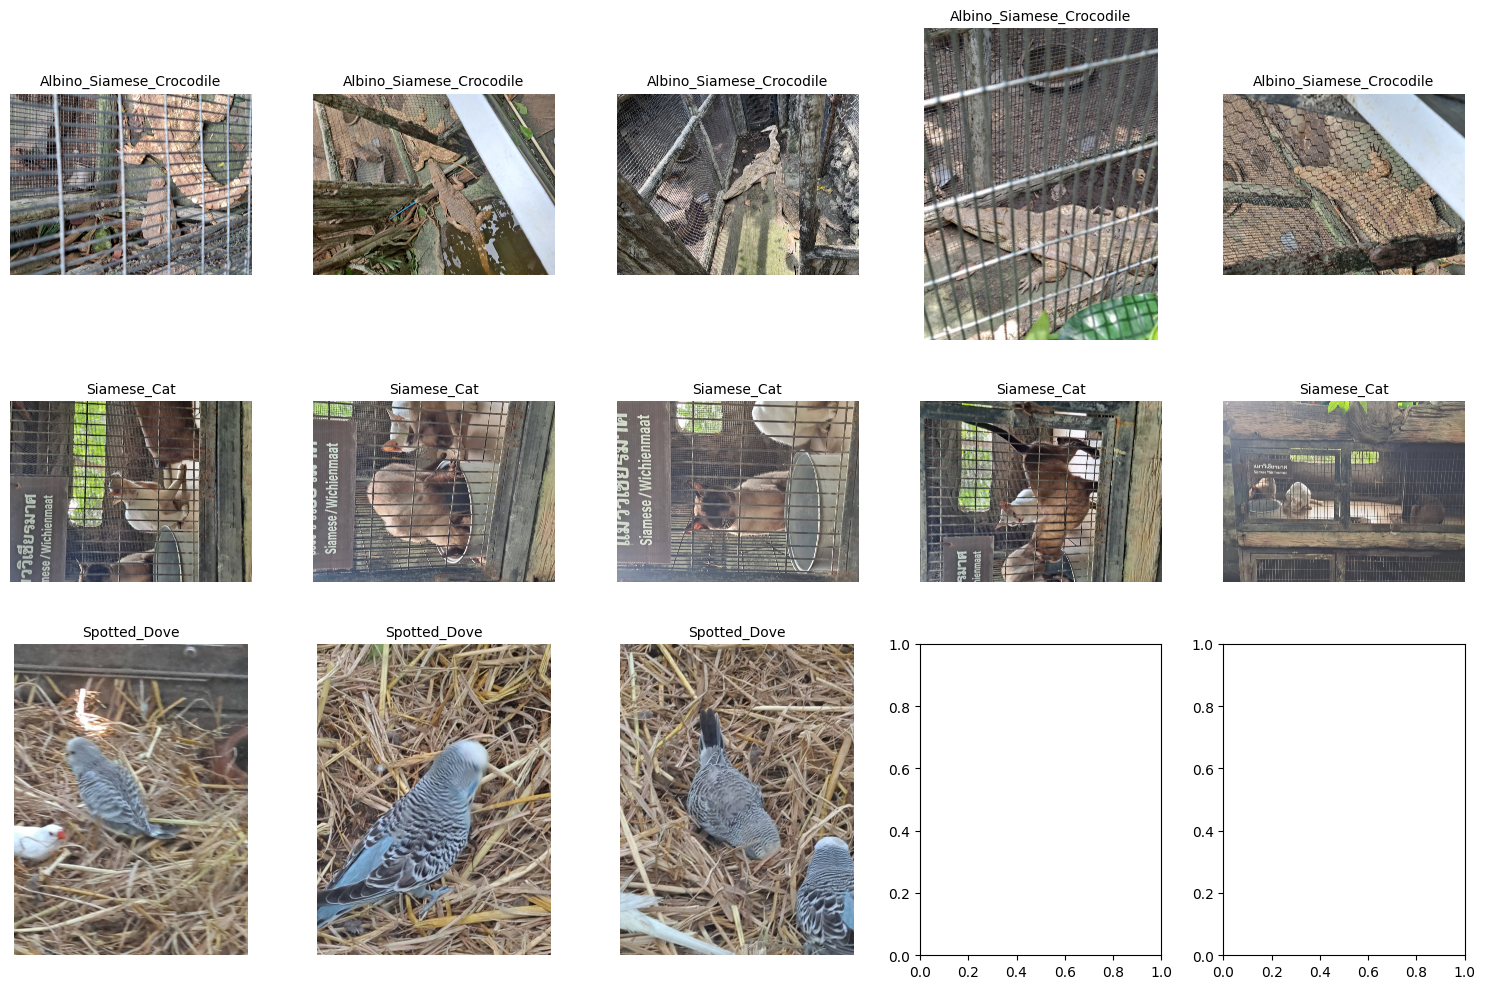

In [ ]:
visual_eda(DATASET_PATH)

## Image Size Summary

In [ ]:
def image_size_summary(base_path):
    base_path = Path(base_path)
    size_counter = Counter()
    total_images = 0

    for img_path in base_path.rglob("*"):
        if img_path.suffix.lower() not in [".jpg", ".jpeg", ".png"]:
            continue

        try:
            with Image.open(img_path) as img:
                size_counter[f"{img.width}x{img.height}"] += 1
                total_images += 1
        except Exception:
            continue

    # Print summary
    print("Image Size Summary:\n")
    for size, count in size_counter.most_common():
        print(f"{size} : {count} images")

    print(f"\nTotal image files counted: {total_images}")

    return size_counter

In [ ]:
image_size_summary(DATASET_PATH)

Image Size Summary:

4624x3468 : 302 images
1108x1477 : 160 images
4032x3024 : 126 images
3024x4032 : 53 images
5712x4284 : 42 images
1477x1108 : 5 images
4284x5712 : 4 images
1198x1562 : 1 images
1034x1568 : 1 images

Total image files counted: 694


Counter({'4624x3468': 302,
         '1108x1477': 160,
         '4032x3024': 126,
         '3024x4032': 53,
         '5712x4284': 42,
         '1477x1108': 5,
         '4284x5712': 4,
         '1198x1562': 1,
         '1034x1568': 1})

# 2. Data Filtering / Selection

## Quantity Filtering

In [ ]:
# Select only classes with more than 20 images
def filter_and_prepare_dataset(src, dest):
    if not dest.exists():
        dest.mkdir(parents=True)
        print(f"Create a New Folder for Experiment: {dest}")

    print(f"Start filtering animals with images >= {NUMBER_OF_CLASS_SPLITS}...")
    print("-" * 50)
    
    selected_classes = 0
    total_images_copied = 0

    # Loop through all animal folders in the source
    for folder in sorted(src.iterdir()):
        # Skip Mac system files (.DS_Store) and other non-directory files
        if folder.is_dir() and not folder.name.startswith('.'):
            # Count only image files
            images = [f for f in folder.iterdir() 
                      if f.suffix.lower() in ['.jpg', '.jpeg', '.png'] 
                      and not f.name.startswith('.')]
            
            count = len(images)
            
            if count >= NUMBER_OF_CLASS_SPLITS:
                dest_folder = dest / folder.name
                
                # If the destination folder already exists, remove it and create a new one (to avoid duplicate data)
                if dest_folder.exists():
                    shutil.rmtree(dest_folder)
                
                shutil.copytree(folder, dest_folder)
                
                print(f"✅ {folder.name:<25} | {count:>3} Images [Copied]")
                selected_classes += 1
                total_images_copied += count
            else:
                # If it doesn't meet the criteria, show that it is skipped
                print(f"❌ {folder.name:<25} | {count:>3} Images [Below threshold - Skipped]")

    print("-" * 50)
    print(f"- Summary: Selected {selected_classes} classes")
    print(f"- Total images ready for training: {total_images_copied}")
    print(f"- Data located at: {dest}")

In [ ]:
filter_and_prepare_dataset(DATASET_PATH_OBJ, DATASET_PLUS)

Create a New Folder for Experiment: /Users/smileymacz/Desktop/WildSnap-Train-20plus
Start filtering animals with images >= 20...
--------------------------------------------------
❌ African_Pygmy_Dormouse    |   4 Images [Below threshold - Skipped]
❌ Albino_Burmese_Python     |  15 Images [Below threshold - Skipped]
✅ Albino_Siamese_Crocodile  |  25 Images [Copied]
✅ Ball_Python               |  31 Images [Copied]
✅ Black-headed_Caique       |  22 Images [Copied]
✅ Blue-and-gold_Macaw       |  47 Images [Copied]
❌ Blue-tongued_Skink        |  16 Images [Below threshold - Skipped]
✅ Budapest_Pigeon           |  22 Images [Copied]
❌ Budgerigar                |   1 Images [Below threshold - Skipped]
✅ Burmese_Python            |  21 Images [Copied]
❌ Cockatiel                 |   7 Images [Below threshold - Skipped]
❌ Cuviers_Dwarf_Caiman      |   5 Images [Below threshold - Skipped]
✅ Gouldian_Finch            |  25 Images [Copied]
✅ Green-cheeked_Conure      |  23 Images [Copied]
✅ Grey

In [ ]:
summarize_dataset(DATASET_PLUS)

----------------------------------------
Animal                    | Image Count
----------------------------------------
Albino_Siamese_Crocodile  | 25         ✅ Ready
Ball_Python               | 31         ✅ Ready
Black-headed_Caique       | 22         ✅ Ready
Blue-and-gold_Macaw       | 47         ✅ Ready
Budapest_Pigeon           | 22         ✅ Ready
Burmese_Python            | 21         ✅ Ready
Gouldian_Finch            | 25         ✅ Ready
Green-cheeked_Conure      | 23         ✅ Ready
Grey_Crowned_Crane        | 43         ✅ Ready
Grey_Parrot               | 26         ✅ Ready
Iguana                    | 30         ✅ Ready
Meerkat                   | 43         ✅ Ready
Muscovy_Duck              | 36         ✅ Ready
Scarlet_Macaw             | 36         ✅ Ready
Silkie_Chicken            | 23         ✅ Ready
Sulphur-crested_Cockatoo  | 52         ✅ Ready
White-bellied_Caique      | 28         ✅ Ready
Yellow Ring-necked_Parakeet | 20         ✅ Ready
------------------------------

# 3. Data Preprocessing

## Resize Image to 214 x 214

In [ ]:
def resize_and_pad(img_path, output_path, size=214):
    try:
        with Image.open(img_path) as img:
            # Convert to RGB (to handle PNG with Alpha channel or CMYK files)
            img = img.convert('RGB')
            
            # Calculate aspect ratio to resize the longest side to 214
            img.thumbnail((size, size), Image.Resampling.LANCZOS)
            
            # Fill with black background image of size 214x214
            new_img = Image.new("RGB", (size, size), (0, 0, 0))
            
            # Place the image in the center of the background
            left = (size - img.width) // 2
            top = (size - img.height) // 2
            new_img.paste(img, (left, top))
            
            new_img.save(output_path, "JPEG", quality=95)
    except Exception as e:
        print(f"❌ Can't process file {img_path.name}: {e}")

In [ ]:
print("Defining image size to 214x214 with black background...")

if not DATASET_PLUS_SIZE.exists():
    DATASET_PLUS_SIZE.mkdir(parents=True)

for class_folder in sorted(DATASET_PLUS.iterdir()):
    if class_folder.is_dir() and not class_folder.name.startswith('.'):
        output_class_dir = DATASET_PLUS_SIZE / class_folder.name
        output_class_dir.mkdir(exist_ok=True)
        
        print(f"Processing: {class_folder.name}...")
        
        for img_file in class_folder.iterdir():
            if img_file.suffix.lower() in ['.jpg', '.jpeg', '.png']:
                output_file_path = output_class_dir / f"{img_file.stem}.jpg"
                resize_and_pad(img_file, output_file_path, size=214)

print(f"\n Finished! All images are saved at: {DATASET_PLUS_SIZE}")

Defining image size to 214x214 with black background...
Processing: Albino_Siamese_Crocodile...
Processing: Ball_Python...
Processing: Black-headed_Caique...
Processing: Blue-and-gold_Macaw...
Processing: Budapest_Pigeon...
Processing: Burmese_Python...
Processing: Gouldian_Finch...
Processing: Green-cheeked_Conure...
Processing: Grey_Crowned_Crane...
Processing: Grey_Parrot...
Processing: Iguana...
Processing: Meerkat...
Processing: Muscovy_Duck...
Processing: Scarlet_Macaw...
Processing: Silkie_Chicken...
Processing: Sulphur-crested_Cockatoo...
Processing: White-bellied_Caique...
Processing: Yellow Ring-necked_Parakeet...

 Finished! All images are saved at: /Users/smileymacz/Desktop/WildSnap-Final-214


In [ ]:
image_size_summary(DATASET_PLUS_SIZE)

Image Size Summary:

214x214 : 637 images

Total image files counted: 637


Counter({'214x214': 637})

# 4. Data Augmentation

In [ ]:
def augment_image(img):
    # Randomly flip image horizontally
    if random.random() > 0.5:
        img = ImageOps.mirror(img)
    
    # Randomly rotate image (-15 to 15 degrees)
    angle = random.randint(-15, 15)
    img = img.rotate(angle, fillcolor=(0,0,0)) # Rotate and fill black border
    
    # Randomly adjust brightness (0.8 to 1.2)
    enhancer = ImageEnhance.Brightness(img)
    img = enhancer.enhance(random.uniform(0.8, 1.2))
    
    return img

In [ ]:
print(f"Starting Augmentation to ensure each class has at least {TARGET_COUNT} images...\n")

for class_folder in sorted(DATASET_PLUS_SIZE.iterdir()):
    if class_folder.is_dir() and not class_folder.name.startswith('.'):
        # Get the list of existing images
        images = [f for f in class_folder.iterdir() if f.suffix.lower() in ['.jpg', '.jpeg', '.png']]
        current_count = len(images)
        
        if current_count < TARGET_COUNT:
            num_to_add = TARGET_COUNT - current_count
            print(f"{class_folder.name}: has {current_count} images, adding {num_to_add} more...")
            
            for i in range(num_to_add):
                # Randomly select one original image to augment
                source_img_path = random.choice(images)
                with Image.open(source_img_path) as img:
                    augmented_img = augment_image(img)
                    
                    new_name = f"aug_{i}_{source_img_path.name}"
                    augmented_img.save(class_folder / new_name, "JPEG", quality=95)
        else:
            print(f"✅ {class_folder.name}: has enough images ({current_count} images)")

print(f"\nDone! Now every class in {DATASET_PLUS_SIZE} has at least {TARGET_COUNT} images.")

Starting Augmentation to ensure each class has at least 60 images...

Albino_Siamese_Crocodile: has 25 images, adding 35 more...
Ball_Python: has 50 images, adding 10 more...
Black-headed_Caique: has 22 images, adding 38 more...
Blue-and-gold_Macaw: has 50 images, adding 10 more...
Budapest_Pigeon: has 22 images, adding 38 more...
Burmese_Python: has 21 images, adding 39 more...
Gouldian_Finch: has 25 images, adding 35 more...
Green-cheeked_Conure: has 23 images, adding 37 more...
Grey_Crowned_Crane: has 50 images, adding 10 more...
Grey_Parrot: has 26 images, adding 34 more...
Iguana: has 50 images, adding 10 more...
Meerkat: has 50 images, adding 10 more...
Muscovy_Duck: has 50 images, adding 10 more...
Scarlet_Macaw: has 50 images, adding 10 more...
Silkie_Chicken: has 23 images, adding 37 more...
Sulphur-crested_Cockatoo: has 52 images, adding 8 more...
White-bellied_Caique: has 28 images, adding 32 more...
Yellow Ring-necked_Parakeet: has 20 images, adding 40 more...

Done! Now ev

In [ ]:
summarize_dataset(DATASET_PLUS_SIZE)

----------------------------------------
Animal                    | Image Count
----------------------------------------
Albino_Siamese_Crocodile  | 60         ✅ Ready
Ball_Python               | 60         ✅ Ready
Black-headed_Caique       | 60         ✅ Ready
Blue-and-gold_Macaw       | 60         ✅ Ready
Budapest_Pigeon           | 60         ✅ Ready
Burmese_Python            | 60         ✅ Ready
Gouldian_Finch            | 60         ✅ Ready
Green-cheeked_Conure      | 60         ✅ Ready
Grey_Crowned_Crane        | 60         ✅ Ready
Grey_Parrot               | 60         ✅ Ready
Iguana                    | 60         ✅ Ready
Meerkat                   | 60         ✅ Ready
Muscovy_Duck              | 60         ✅ Ready
Scarlet_Macaw             | 59         ✅ Ready
Silkie_Chicken            | 60         ✅ Ready
Sulphur-crested_Cockatoo  | 60         ✅ Ready
White-bellied_Caique      | 60         ✅ Ready
Yellow Ring-necked_Parakeet | 60         ✅ Ready
------------------------------

# 5. Data Splitting

In [ ]:
def split_dataset(input_folder, output_folder):
    if not output_folder.exists():
        output_folder.mkdir(parents=True)
    
    print("Splitting dataset with Train/Val/Test ratio of 80/10/10...")
    
    splitfolders.ratio(input_folder, output=output_folder, 
                       seed=1337, ratio=(.8, .1, .1), 
                       group_prefix=None, move=False)
    
    print("Dataset split completed.")

In [ ]:
split_dataset(DATASET_PLUS_SIZE, DATASET_PLUS_SIZE_SPLIT)

Splitting dataset with Train/Val/Test ratio of 80/10/10...
Dataset split completed.


# 6. Data Loader

## Tensor Conversion & Normalization

In [ ]:
def define_normalization_transforms():
    data_transforms = {
        'train': transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(NORM_MEAN, NORM_STD)
        ]),
        'val': transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(NORM_MEAN, NORM_STD)
        ]),
    }

    print("✅ Normalization transforms defined successfully")
    return data_transforms

In [ ]:
data_transforms = define_normalization_transforms()
data_transforms

✅ Normalization transforms defined successfully


{'train': Compose(
     ToTensor()
     Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
 ),
 'val': Compose(
     ToTensor()
     Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
 )}

In [ ]:
# Create Dataset with transforms (including Normalization)
image_datasets = {
    x: datasets.ImageFolder(DATASET_PLUS_SIZE_SPLIT / x, data_transforms[x])
    for x in ['train', 'val']
}

# 2. Create DataLoader (data conveyor belt)
dataloaders = {
    x: DataLoader(image_datasets[x], batch_size=16, shuffle=True)
    for x in ['train', 'val']
}

In [ ]:
# Analyze dataset sizes and classes
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}
class_names = image_datasets['train'].classes

print(f"Summary of normalized data:")
print(f"- Number of Classes: {len(class_names)} types")
print(f"- Training images: {dataset_sizes['train']} images")
print(f"- Validation images: {dataset_sizes['val']} images")

Summary of normalized data:
- Number of Classes: 18 types
- Training images: 880 images
- Validation images: 119 images


# 7. Define Model

In [ ]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"🚀 Using Device: {device}")

# Load pre-trained EfficientNet-B0 model
model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)

# Adjust the classifier head to match the number of your animal classes
num_ftrs = model.classifier[1].in_features
model.classifier[1] = nn.Linear(num_ftrs, len(class_names))

# Move the model to GPU/CPU
model = model.to(device)

# 4. Define Loss function and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(f"✅ Model defined successfully, ready to classify {len(class_names)} animal types")

🚀 Using Device: mps
✅ Model defined successfully, ready to classify 18 animal types


# 8. Start Training

In [ ]:
def train_model(model, criterion, optimizer, num_epochs=10):
    since = time.time()
    
    # Store training history
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 10)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                # Forward Pass (let AI predict)
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    # Backward Pass (fine-tune only during training)
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.cpu().float() / dataset_sizes[phase]

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')
            
            if phase == 'train':
                history['train_loss'].append(epoch_loss)
                history['train_acc'].append(epoch_acc.item())
            else:
                history['val_loss'].append(epoch_loss)
                history['val_acc'].append(epoch_acc.item())

    time_elapsed = time.time() - since
    print(f'\nTraining completed in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    return model, history

In [ ]:
# Start training (try starting with 10-15 epochs first)
trained_model, train_history = train_model(model, criterion, optimizer, num_epochs=15)

Epoch 1/15
----------
train Loss: 0.9198 Acc: 0.7670
val Loss: 0.0609 Acc: 0.9916
Epoch 2/15
----------
train Loss: 0.1864 Acc: 0.9511
val Loss: 0.0452 Acc: 0.9916
Epoch 3/15
----------
train Loss: 0.2036 Acc: 0.9409
val Loss: 0.1069 Acc: 0.9748
Epoch 4/15
----------
train Loss: 0.1189 Acc: 0.9614
val Loss: 0.0644 Acc: 0.9916
Epoch 5/15
----------
train Loss: 0.2330 Acc: 0.9341
val Loss: 0.1391 Acc: 0.9580
Epoch 6/15
----------
train Loss: 0.0782 Acc: 0.9795
val Loss: 0.0039 Acc: 1.0000
Epoch 7/15
----------
train Loss: 0.0444 Acc: 0.9886
val Loss: 0.0089 Acc: 1.0000
Epoch 8/15
----------
train Loss: 0.0817 Acc: 0.9773
val Loss: 0.0062 Acc: 1.0000
Epoch 9/15
----------
train Loss: 0.0563 Acc: 0.9852
val Loss: 0.0144 Acc: 0.9916
Epoch 10/15
----------
train Loss: 0.0608 Acc: 0.9807
val Loss: 0.0019 Acc: 1.0000
Epoch 11/15
----------
train Loss: 0.0427 Acc: 0.9875
val Loss: 0.0116 Acc: 0.9916
Epoch 12/15
----------
train Loss: 0.0402 Acc: 0.9886
val Loss: 0.0146 Acc: 0.9916
Epoch 13/15
-

# 9. Result Testing

## Learning Curves Result

In [ ]:
def plot_history(history):
    acc = history['train_acc']
    val_acc = history['val_acc']
    loss = history['train_loss']
    val_loss = history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(12, 5))
    
    # Accuracy graph
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.legend()

    # Loss graph
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    
    plt.show()

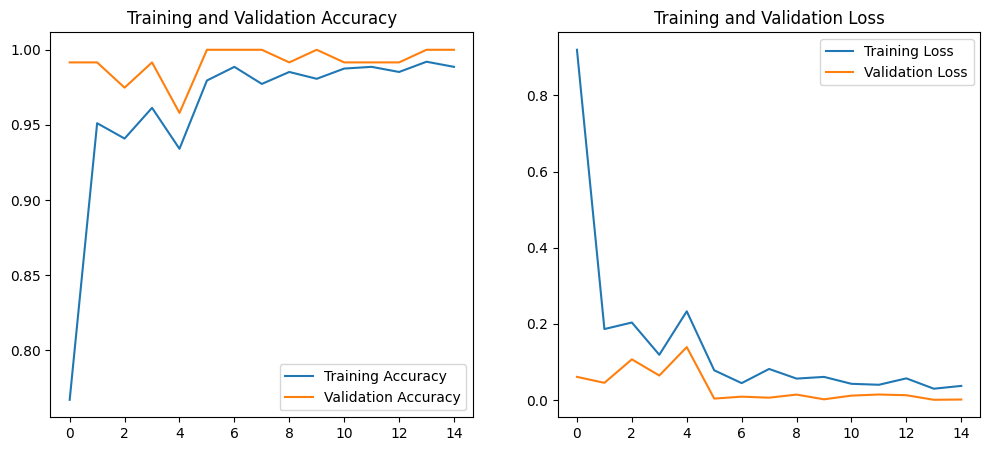

In [ ]:
plot_history(train_history)

## Confusion Matrix

In [ ]:
def show_confusion_matrix(model, dataloader):
    model.eval()
    y_true = []
    y_pred = []
    
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()

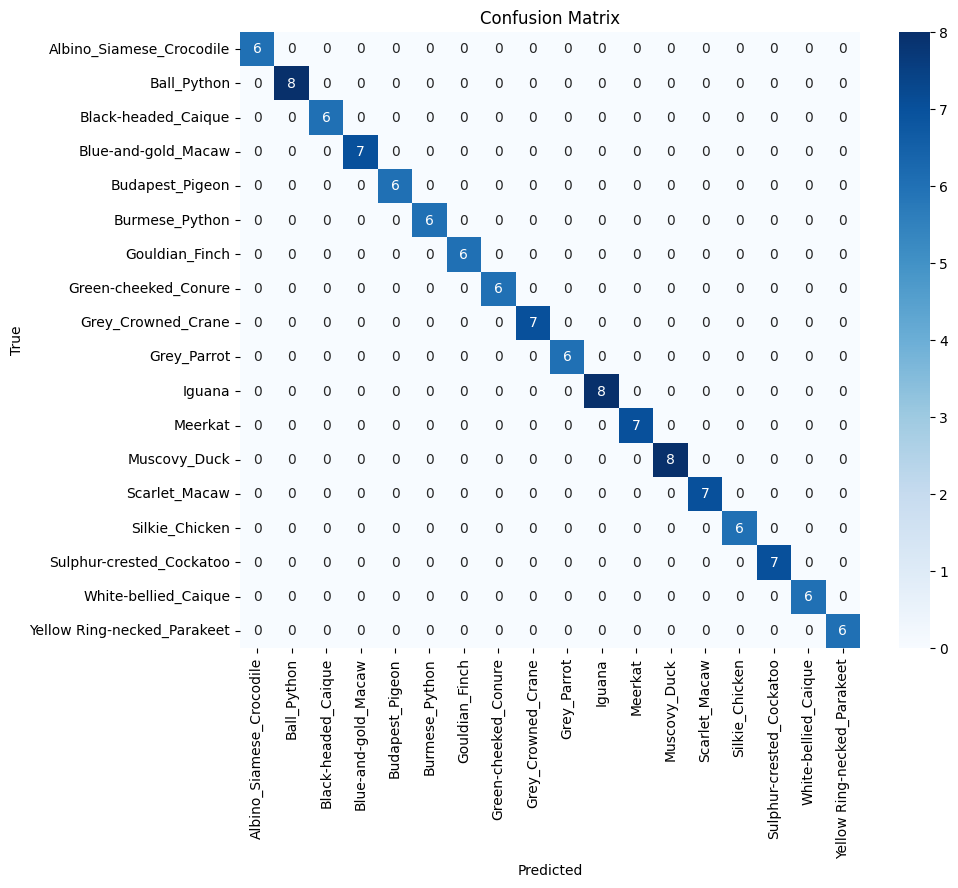

In [ ]:
show_confusion_matrix(trained_model, dataloaders['val'])

## Test Model

In [ ]:
test_dataset = datasets.ImageFolder(DATASET_PLUS_SIZE_SPLIT / 'test', data_transforms['val'])

test_dataloader = DataLoader(test_dataset, batch_size=16, shuffle=False)

print(f"Number of images in the final test set: {len(test_dataset)} images")

Number of images in the final test set: 121 images


In [ ]:
def evaluate_test_set(model, dataloader):
    model.eval()
    running_corrects = 0
    
    print("Starting test evaluation...")
    
    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            
            running_corrects += torch.sum(preds == labels.data)
            
    test_acc = running_corrects.cpu().float() / len(dataloader.dataset)
    print(f"\nTest Set Accuracy (unseen data): {test_acc:.4f} ({test_acc*100:.2f}%)")
    return test_acc

In [ ]:
final_test_acc = evaluate_test_set(trained_model, test_dataloader)

Starting test evaluation...

Test Set Accuracy (unseen data): 0.9917 (99.17%)


In [ ]:
def evaluate_test_set_internet(model, image_path):
    img = Image.open(image_path).convert('RGB')
    # Use the same transform as validation (Resize + Normalize)
    transform = data_transforms['val']
    img_tensor = transform(img).unsqueeze(0).to(device)
    
    model.eval()
    with torch.no_grad():
        output = model(img_tensor)
        prob = torch.nn.functional.softmax(output[0], dim=0)
        conf, pred = torch.max(prob, 0)
    
    plt.imshow(img)
    plt.title(f"Prediction: {class_names[pred]} ({conf*100:.2f}%)")
    plt.axis('off')
    plt.show()

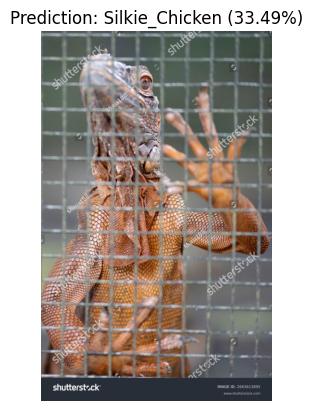

In [ ]:
test_image = Path("~/Downloads/iguna01.jpg").expanduser()
evaluate_test_set_internet(trained_model, test_image)

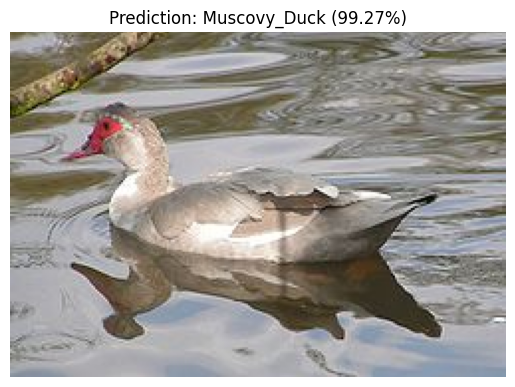

In [ ]:
test_image = Path("~/Downloads/duck01.jpg").expanduser()
evaluate_test_set_internet(trained_model, test_image)

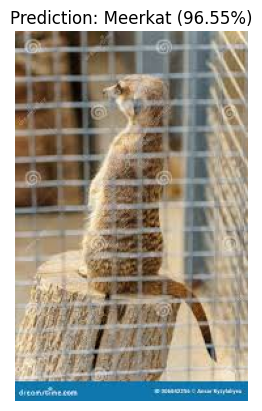

In [ ]:
test_image = Path("~/Downloads/meercat01.jpeg").expanduser()
evaluate_test_set_internet(trained_model, test_image)

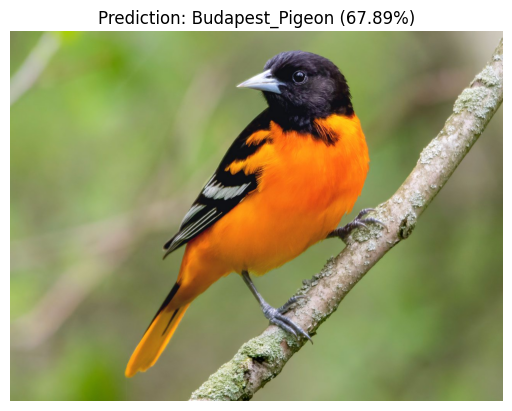

In [ ]:
test_image = Path("~/Downloads/unknow-bird01.jpg").expanduser()
evaluate_test_set_internet(trained_model, test_image)

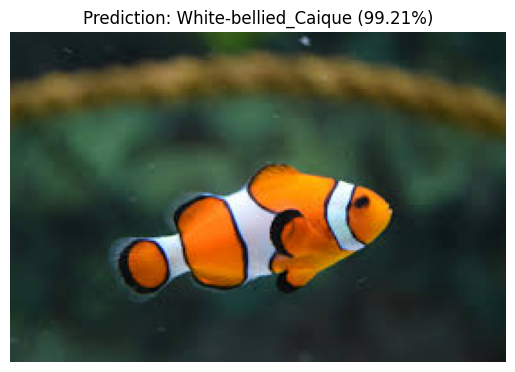

In [ ]:
test_image = Path("~/Downloads/fish01.jpeg").expanduser()
evaluate_test_set_internet(trained_model, test_image)

# 10. Save Model

In [ ]:
# Save the trained model
torch.save(trained_model.state_dict(), EXPORT_MODEL)
print(f"Saved the trained model as {EXPORT_MODEL}")

Saved the trained model as wildsnap_model.pth
